In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available : True


In [ ]:
# Tensor 생성 방법들

# 리스트에서 직접 생성
t1 = torch.tensor([1, 2, 3, 4])
print("리스트에서 생성:", t1)

# 특정 값으로 초기화
zeros = torch.zeros(3, 4)
ones = torch.ones(3, 4)
rand = torch.rand(3, 4) # 균등분포 [0, 1)
randn = torch.randn(3, 4) # 표준정규분포 N(0, 1)

print("\ntorch.zeros(3,4):\n", zeros)
print("\ntorch.randn(3,4):\n", randn.round(decimals=3))

리스트에서 생성: tensor([1, 2, 3, 4])

torch.zeros(3,4):
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

torch.randn(3,4):
 tensor([[-0.2190,  0.9990, -0.0710, -1.0130],
        [-0.2920, -0.2060,  0.6780,  0.6450],
        [-0.3550,  0.5960,  0.6530, -0.7380]])


In [ ]:
# Tensor 속성

x = torch.randn(2, 3, 4)

print("shape :", x.shape) # 차원 크기 (torch.Size)
print("ndim :", x.ndim) # 차원 수
print("dtype :", x.dtype) # 데이터 타입 (기본: float32)
print("device :", x.device) # 저장 위치 (cpu / cuda)
print("numel :", x.numel()) # 전체 원소 개수

shape : torch.Size([2, 3, 4])
ndim : 3
dtype : torch.float32
device : cpu
numel : 24


In [ ]:
# dtype 종류

# 딥러닝에서 자주 쓰는 dtype
a = torch.tensor([1.0, 2.0, 3.0]) # float32 (기본)
b = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64)
c = torch.tensor([1, 2, 3], dtype=torch.int64) # 정수 (레이블 등에 사용)
d = torch.tensor([True, False, True]) # bool

print("float32:", a.dtype)
print("float64:", b.dtype)
print("int64 :", c.dtype)
print("bool :", d.dtype)

# dtype 변환
a_int = a.to(torch.int32)
print("\nfloat -> int32:", a_int)

float32: torch.float32
float64: torch.float64
int64 : torch.int64
bool : torch.bool

float -> int32: tensor([1, 2, 3], dtype=torch.int32)


In [ ]:
# NumPy ↔ Tensor 변환

arr = np.array([[1.0, 2.0], [3.0, 4.0]])

# NumPy → Tensor
t = torch.from_numpy(arr)
print("NumPy → Tensor:\n", t)

# Tensor → NumPy
arr2 = t.numpy()
print("Tensor → NumPy:\n", arr2)

# 메모리 공유 주의: from_numpy()로 만든 텐서는 원본 배열과 메모리를 공유.
arr[0, 0] = 99
print("\narr 수정 후 tensor:", t) # t도 바뀜

NumPy → Tensor:
 tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)
Tensor → NumPy:
 [[1. 2.]
 [3. 4.]]

arr 수정 후 tensor: tensor([[99.,  2.],
        [ 3.,  4.]], dtype=torch.float64)


In [ ]:
# 기본 사칙연산

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("a + b :", a + b) # 덧셈
print("a * b :", a * b) # 원소별 곱셈
print("a ** 2:", a ** 2) # 제곱
print("a.sum():", a.sum()) # 합계
print("a.mean():", a.mean()) # 평균

a + b : tensor([5., 7., 9.])
a * b : tensor([ 4., 10., 18.])
a ** 2: tensor([1., 4., 9.])
a.sum(): tensor(6.)
a.mean(): tensor(2.)


In [ ]:
# 행렬 연산

W = torch.randn(4, 3) # (출력 차원, 입력 차원)
x = torch.randn(3) # 입력벡터

# 행렬-벡터 곱: W @ x = Wx
out = W @ x
print("W shape:", W.shape)
print("x shape:", x.shape)
print("W @ x shape:", out.shape)

# 배치(batch) 처리: 여러 샘플을 한번에
X_batch = torch.randn(8, 3) # 8개 샘플, 각 차원 = 3
out_batch = X_batch @ W.T # (8, 4)
print("\n배치 출력 shape (8샘플):", out_batch.shape)

W shape: torch.Size([4, 3])
x shape: torch.Size([3])
W @ x shape: torch.Size([4])

배치 출력 shape (8샘플): torch.Size([8, 4])


In [ ]:
# Shape 변환

x = torch.arange(24, dtype=torch.float32)
print("원본 shape:", x.shape)

# reshape: 원소 수가 같다면 자유롭게 변환 가능
x2d = x.reshape(4, 6)
x3d = x.reshape(2, 3, 4)
print("reshape(4,6) :", x2d.shape)
print("reshape(2,3,4):", x3d.shape)
print(x)
print(x2d)
print(x3d)

# -1: 해당 차원을 자동 계산
x_auto = x.reshape(4, -1) # 4 × ? = 24 → 4×6
print("reshape(4,-1) :", x_auto.shape)

# view vs reshape: view는 연속 메모리가 보장될 때만 동작
# flatten: 모든 차원을 1D로
x_flat = x3d.flatten()
print("flatten :", x_flat.shape)


원본 shape: torch.Size([24])
reshape(4,6) : torch.Size([4, 6])
reshape(2,3,4): torch.Size([2, 3, 4])
tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23.])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.],
        [12., 13., 14., 15., 16., 17.],
        [18., 19., 20., 21., 22., 23.]])
tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])
reshape(4,-1) : torch.Size([4, 6])
flatten : torch.Size([24])


In [ ]:
# 차원 추가/제거

x = torch.tensor([1.0, 2.0, 3.0]) # shape: (3,)

# unsqueeze: 차원 추가
x_row = x.unsqueeze(0) # (1, 3) — 행 벡터
x_col = x.unsqueeze(1) # (3, 1) — 열 벡터
print("원본 :", x.shape)
print("unsqueeze(0):", x_row.shape)
print("unsqueeze(1):", x_col.shape)

# squeeze: 크기가 1인 차원 제거
x_back = x_row.squeeze(0) # (3,)
print("squeeze(0) :", x_back.shape)

원본 : torch.Size([3])
unsqueeze(0): torch.Size([1, 3])
unsqueeze(1): torch.Size([3, 1])
squeeze(0) : torch.Size([3])


In [ ]:
# 인덱싱 & 슬라이싱

x = torch.arange(16, dtype=torch.float32).reshape(4, 4)
print("x:\n", x)
print()
print("x[0]      :", x[0]) # 첫 번째 행
print("x[:, 1]   :", x[:, 1]) # 두 번째 열
print("x[1:3, :]:\n", x[1:3, :]) # 1~2행

# 조건부 인덱싱 (Boolean Masking)
mask = x > 8
print("\nx > 8인 원소:", x[mask])

x:
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]])

x[0]      : tensor([0., 1., 2., 3.])
x[:, 1]   : tensor([ 1.,  5.,  9., 13.])
x[1:3, :]:
 tensor([[ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

x > 8인 원소: tensor([ 9., 10., 11., 12., 13., 14., 15.])


In [ ]:
## GPU 사용하기

# device 설정: GPU가 있으면 cuda, 없으면 cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 device:", device)

# Tensor를 GPU로 이동
x = torch.randn(3, 3)

x_gpu = x.to(device) # .to(device)
# x_gpu = x.cuda() # 또는 .cuda() (GPU가 있을 때만)
print("x device:", x.device)
print("x_gpu device:", x_gpu.device)

# 주의: 연산하는 두 텐서는 반드시 같은 device에 있어야 함
# x + x_gpu → 오류 발생
# GPU → CPU (numpy 변환 전 필요)
x_cpu = x_gpu.cpu()
print("cpu로 이동:", x_cpu.device)

사용 device: cuda
x device: cpu
x_gpu device: cuda:0
cpu로 이동: cpu


In [ ]:
## Autograd — 자동 미분
# 기본 사용법

x = torch.tensor(3.0, requires_grad=True)

# y = x^2 + 2x + 1
y = x**2 + 2*x + 1
print("y = x² + 2x + 1 =", y.item())

# 역전파
y.backward()

# dy/dx = 2x + 2 = 2(3) + 2 = 8
print("dy/dx =", x.grad.item(), " (이론값: 2 × 3 + 2 = 8)")

y = x² + 2x + 1 = 16.0
dy/dx = 8.0  (이론값: 2 × 3 + 2 = 8)


In [ ]:
# 벡터에서의 Autograd

W = torch.randn(3, 2, requires_grad=True)
x = torch.randn(2)
out = (W @ x).sum() # 스칼라로 만든 후 backward
out.backward()

print("W.grad shape:", W.grad.shape) # W와 동일한 shape
print("W.grad:\n", W.grad)

W.grad shape: torch.Size([3, 2])
W.grad:
 tensor([[-1.4032, -0.8195],
        [-1.4032, -0.8195],
        [-1.4032, -0.8195]])


In [ ]:
# 기울기 초기화

# 중요: backward()를 여러 번 호출하면 기울기가 누적
x = torch.tensor(2.0, requires_grad=True)

for i in range(3):
  y = x ** 2
  y.backward()

  print(f"step {i+1}: x.grad = {x.grad.item():.1f}")
  x.grad.zero_() # ← 반드시 초기화! (옵티마이저가 자동으로 해주기도 함)

step 1: x.grad = 4.0
step 2: x.grad = 4.0
step 3: x.grad = 4.0


In [ ]:
#  torch.no_grad()

# 추론(inference) 시에는 기울기 계산이 필요 x → 메모리/속도 절약
x = torch.randn(3, requires_grad=True)

with torch.no_grad():
  y = x * 2 # 기울기 추적 안 함

print("requires_grad inside no_grad:", y.requires_grad) # False

requires_grad inside no_grad: False


In [ ]:
## nn.Module — 신경망 구성
# 자주 쓰는 레이어들

# nn.Linear: 완전연결층 (y = xW^T + b)
linear = nn.Linear(in_features=4, out_features=8)

print("nn.Linear(4→8)")
print(" weight shape:", linear.weight.shape) # (8, 4)
print(" bias shape:", linear.bias.shape) # (8,)

x = torch.randn(2, 4) # 배치 크기 2, 차원 4
out = linear(x)

print(" input shape:", x.shape)
print(" output shape:", out.shape)

nn.Linear(4→8)
 weight shape: torch.Size([8, 4])
 bias shape: torch.Size([8])
 input shape: torch.Size([2, 4])
 output shape: torch.Size([2, 8])


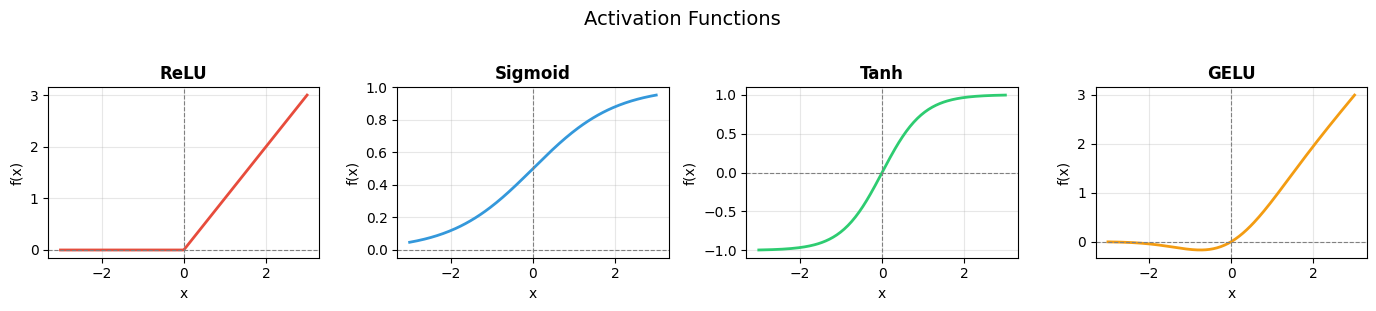

In [ ]:
# 활성화 함수 (Activation Functions)

# 비선형성을 도입하여 복잡한 패턴 학습
x = torch.linspace(-3, 3, 200)
activations = {
'ReLU' : nn.ReLU(),
'Sigmoid' : nn.Sigmoid(),
'Tanh' : nn.Tanh(),
'GELU' : nn.GELU(),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, (name, fn), color in zip(axes, activations.items(), colors):
  y = fn(x).detach()
  ax.plot(x.numpy(), y.numpy(), color=color, lw=2)
  ax.axhline(0, color='gray', lw=0.8, ls='--')
  ax.axvline(0, color='gray', lw=0.8, ls='--')
  ax.set_title(name, fontsize=12, fontweight='bold')
  ax.set_xlabel('x'); ax.set_ylabel('f(x)')
  ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 활성화 함수 비교 표

# 각 활성화 함수의 특징
info = {
'ReLU' : 'max(0, x) — 가장 많이 쓰임, 빠름, dying ReLU 문제',
'LeakyReLU': 'max(αx, x), α=0.01 — Dying ReLU 방지',
'Sigmoid': '1/(1+e^-x) ∈ (0,1) — 이진 분류 출력에 사용',
'Tanh' : '(e^x-e^-x)/(e^x+e^-x) ∈ (-1,1) — RNN에 자주 사용',
'GELU' : 'x·Φ(x) — Transformer에 사용 (BERT 등)',
'Softmax': 'exp(x_i)/Σexp(x_j) — 다중 클래스 출력 확률화',
}

print("활성화 함수\t설명")
print("-" * 70)
for name, desc in info.items():
  print(f"{name:<12}\t{desc}")

활성화 함수	설명
----------------------------------------------------------------------
ReLU        	max(0, x) — 가장 많이 쓰임, 빠름, dying ReLU 문제
LeakyReLU   	max(αx, x), α=0.01 — Dying ReLU 방지
Sigmoid     	1/(1+e^-x) ∈ (0,1) — 이진 분류 출력에 사용
Tanh        	(e^x-e^-x)/(e^x+e^-x) ∈ (-1,1) — RNN에 자주 사용
GELU        	x·Φ(x) — Transformer에 사용 (BERT 등)
Softmax     	exp(x_i)/Σexp(x_j) — 다중 클래스 출력 확률화


In [ ]:
#  nn.Sequential — 레이어를 순서대로 쌓기

# 간단한 모델에 적합한 방식
model_seq = nn.Sequential(
nn.Linear(4, 16),
nn.ReLU(),
nn.Linear(16, 8),
nn.ReLU(),
nn.Linear(8, 2),
)

x = torch.randn(5, 4)
out = model_seq(x)
print("모델 구조:\n", model_seq)
print("\n입력 shape:", x.shape)
print("출력 shape:", out.shape)

모델 구조:
 Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=2, bias=True)
)

입력 shape: torch.Size([5, 4])
출력 shape: torch.Size([5, 2])


In [ ]:
# 커스텀 모델 — nn.Module 상속

# 더 복잡한 구조가 필요할 때 사용
class MLP(nn.Module):
    """
    Multi-Layer Perceptron (다층 퍼셉트론)
    input_dim → hidden_dim → hidden_dim → output_dim
    """
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__() # 반드시 호출

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):

        # x: (batch, input_dim)
        x = self.relu(self.fc1(x)) # (batch, hidden_dim)
        x = self.relu(self.fc2(x)) # (batch, hidden_dim)
        x = self.fc3(x) # (batch, hidden_dim)
        return x

model = MLP(input_dim=10, hidden_dim=64, output_dim=3)
print(model)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n총 파라미터 수 : {total_params:,}")
print(f"학습 가능 파라미터 : {trainable:,}")

MLP(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
  (relu): ReLU()
)

총 파라미터 수 : 5,059
학습 가능 파라미터 : 5,059


In [ ]:
# 학습/평가 모드

# Dropout, BatchNorm 등은 학습/평가 시 동작이 다름!
model.train() # 학습 모드 (기본값)
print("학습 모드:", model.training)
model.eval() # 평가 모드
print("평가 모드:", model.training)

학습 모드: True
평가 모드: False


In [ ]:
## 손실 함수 (Loss Functions)

# 분류 문제
# CrossEntropyLoss = Softmax + NLLLoss
# input: raw logits (N, C), target: class index (N,)
criterion_ce = nn.CrossEntropyLoss()
logits = torch.tensor([[2.5, 0.3, -1.0],
[0.1, 3.2, 0.5]])
labels = torch.tensor([0, 1]) # 정답 클래스
loss_ce = criterion_ce(logits, labels)
print("CrossEntropyLoss:", loss_ce.item())

# 회귀 문제
criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss() # Mean Squared Error

# Mean Absolute Error
pred = torch.tensor([1.0, 2.0, 3.0])
target = torch.tensor([1.5, 2.5, 2.0])
print("\nMSELoss:", criterion_mse(pred, target).item())
print("L1Loss :", criterion_mae(pred, target).item())

# 이진 분류
criterion_bce = nn.BCEWithLogitsLoss() # Sigmoid + BCE
logits_bin = torch.tensor([1.5, -0.5, 2.0])
labels_bin = torch.tensor([1.0, 0.0, 1.0])
print("\nBCEWithLogitsLoss:", criterion_bce(logits_bin, labels_bin).item())

CrossEntropyLoss: 0.11914738267660141

MSELoss: 0.5
L1Loss : 0.6666666865348816

BCEWithLogitsLoss: 0.2674727737903595


In [ ]:
##  옵티마이저 (Optimizer)

model = MLP(input_dim=10, hidden_dim=64, output_dim=3)

# 옵티마이저 생성: model.parameters() 전달
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01)
optimizer_sgdm = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999))
optimizer_adamw= optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

# 실제 사용 예 (Adam)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 업데이트 1스텝
x_dummy = torch.randn(4, 10)
y_dummy = torch.tensor([0, 1, 2, 0])
optimizer.zero_grad() # 1) 기울기 초기화
out = model(x_dummy) # 2) Forward pass
loss = nn.CrossEntropyLoss()(out, y_dummy) # 3) Loss 계산
loss.backward() # 4) Backward pass
optimizer.step() # 5) 파라미터 업데이트
print("1 step loss:", loss.item())

1 step loss: 1.0321475267410278


In [ ]:
## 학습루프

n_epochs = 10 # 예시: 10 에포크

# 더미 데이터로 dataloader 역할을 할 리스트를 생성
# 실제 구현에서는 torch.utils.data.DataLoader를 사용
dummy_inputs = torch.randn(4, 10) # 예시 입력 데이터 (배치 크기 4, 특성 10)
dummy_targets = torch.randint(0, 3, (4,)) # 예시 타겟 레이블 (배치 크기 4, 클래스 0, 1, 2 중 하나)

# 하나의 배치만 포함하는 더미 dataloader
dataloader = [(dummy_inputs, dummy_targets)]

criterion = nn.CrossEntropyLoss() # 손실 함수 (이전 셀에서 정의된 것을 활용하거나 다시 정의)

for epoch in range(n_epochs):
  print(f"\nEpoch {epoch+1}/{n_epochs}")

  for batch_idx, (inputs, targets) in enumerate(dataloader): # 미니배치
    optimizer.zero_grad() # 1 기울기 초기화
    pred = model(inputs) # 2 Forward
    loss = criterion(pred, targets) # 3 Loss
    loss.backward() # 4 Backward
    optimizer.step() # 5 Update

    print(f"  Batch {batch_idx+1}: Loss = {loss.item():.4f}")



Epoch 1/10
  Batch 1: Loss = 0.9096

Epoch 2/10
  Batch 1: Loss = 0.8996

Epoch 3/10
  Batch 1: Loss = 0.8830

Epoch 4/10
  Batch 1: Loss = 0.8618

Epoch 5/10
  Batch 1: Loss = 0.8375

Epoch 6/10
  Batch 1: Loss = 0.8107

Epoch 7/10
  Batch 1: Loss = 0.7822

Epoch 8/10
  Batch 1: Loss = 0.7529

Epoch 9/10
  Batch 1: Loss = 0.7228

Epoch 10/10
  Batch 1: Loss = 0.6923


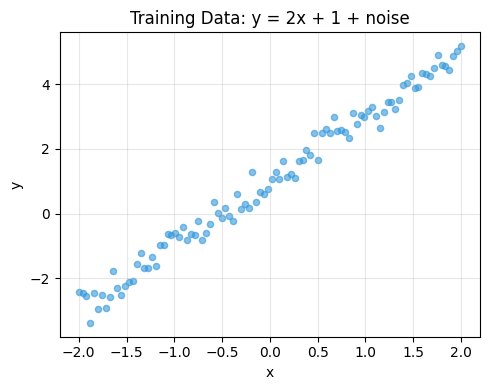

In [ ]:
# 데이터 준비: y = 2x + 1 + noise

torch.manual_seed(42)
N = 100
X_data = torch.linspace(-2, 2, N).unsqueeze(1)
y_data = 2 * X_data + 1 + 0.3 * torch.randn(N, 1) # (100, 1)

# (100, 1)
plt.figure(figsize=(5, 4))
plt.scatter(X_data.numpy(), y_data.numpy(), alpha=0.6, s=20, color='#3498db')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Training Data: y = 2x + 1 + noise')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 모델 / Loss / Optimizer 정의

reg_model = nn.Linear(1, 1) # 단순 선형 회귀: y = wx + b
criterion = nn.MSELoss()
optimizer = optim.SGD(reg_model.parameters(), lr=0.05)

print("초기 파라미터:")
print(f" w = {reg_model.weight.item():.4f}")
print(f" b = {reg_model.bias.item():.4f}")

초기 파라미터:
 w = -0.4309
 b = -0.5987


In [ ]:
# 학습 루프

n_epochs = 200
loss_history = []
reg_model.train()

for epoch in range(n_epochs):
  optimizer.zero_grad() # ① 기울기 초기화
  pred = reg_model(X_data) # ② Forward
  loss = criterion(pred, y_data) # ③ Loss
  loss.backward() # ④ Backward
  optimizer.step() # ⑤ Update
loss_history.append(loss.item())

if (epoch + 1) % 50 == 0:
  print(f"Epoch {epoch+1:3d}/{n_epochs} loss={loss.item():.4f}")
  print("\n학습 후 파라미터:")
  print(f" w = {reg_model.weight.item():.4f} (정답: 2.0)")
  print(f" b = {reg_model.bias.item():.4f} (정답: 1.0)")

Epoch 200/200 loss=0.0867

학습 후 파라미터:
 w = 1.9956 (정답: 2.0)
 b = 1.0179 (정답: 1.0)


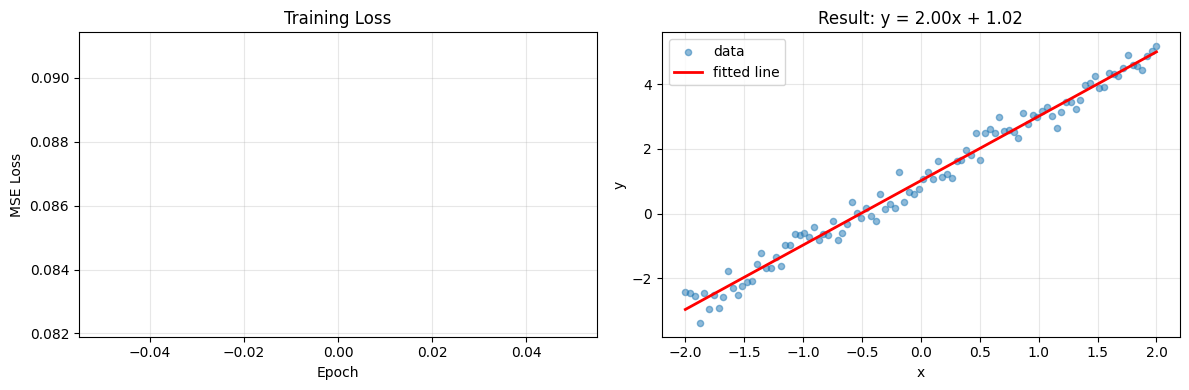

In [ ]:
# 결과 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss Curve
axes[0].plot(loss_history, color='#e74c3c', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Fitted Line
reg_model.eval()
with torch.no_grad():
  x_line = torch.linspace(-2, 2, 100).unsqueeze(1)
  y_line = reg_model(x_line)

axes[1].scatter(X_data.numpy(), y_data.numpy(), alpha=0.5, s=20, label='data')
axes[1].plot(x_line.numpy(), y_line.numpy(), 'r-', lw=2, label='fitted line')
w = reg_model.weight.item()
b = reg_model.bias.item()
axes[1].set_title(f'Result: y = {w:.2f}x + {b:.2f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
##  모델 저장 & 불러오기

import os
os.makedirs('saved_models', exist_ok=True)
SAVE_PATH = 'saved_models/reg_model.pth'

#  저장
# 권장: state_dict만 저장 (모델 클래스 정의 필요)
torch.save(reg_model.state_dict(), SAVE_PATH)
print("모델 저장 완료:", SAVE_PATH)
print("state_dict keys:", list(reg_model.state_dict().keys()))
#  불러오기
loaded_model = nn.Linear(1, 1) # 모델 구조 재생성
loaded_model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
loaded_model.eval()

# 저장 전/후 예측 비교
x_test = torch.tensor([[1.5]])
with torch.no_grad():
  print(f"\n원본 모델 예측: {reg_model(x_test).item():.4f}")
  print(f"로드된 모델 예측: {loaded_model(x_test).item():.4f}")

모델 저장 완료: saved_models/reg_model.pth
state_dict keys: ['weight', 'bias']

원본 모델 예측: 4.0113
로드된 모델 예측: 4.0113


In [1]:
# 연습문제1
import torch

# 텐서 생성
x = torch.arange(1, 13)

# (3, 4)
a = x.reshape(3, 4)

# (2, 2, 3)
b = x.reshape(2, 2, 3)

# (1, 12)
c = x.reshape(1, 12)

print("original:", x)
print("(3,4):\n", a)
print("(2,2,3):\n", b)
print("(1,12):\n", c)

original: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
(3,4):
 tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
(2,2,3):
 tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])
(1,12):
 tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]])


In [3]:
# 연습문제2
import torch

# x 정의 (gradient 추적)
x = torch.tensor(2.0, requires_grad=True)

# 함수 정의
f = x**3 - 3*x**2 + 2

# 미분 계산
f.backward()

print("Autograd gradient:", x.grad)

# 이론값
theoretical = 3*(2**2) - 6*2
print("Theoretical gradient:", theoretical)

Autograd gradient: tensor(0.)
Theoretical gradient: 0


In [4]:
# 연습문제4
import torch
import torch.nn as nn
import torch.optim as optim

# 데이터 생성
X = torch.randn(200, 4)
y = (X[:, 0] + X[:, 1] > 0).long()

# 3층 MLP 모델
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 2)
)

# 손실 함수 / optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 학습
for epoch in range(100):

    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch}, loss {loss.item():.4f}")

# 정확도 계산
with torch.no_grad():
    preds = model(X).argmax(dim=1)
    acc = (preds == y).float().mean()

print("Accuracy:", acc.item())

epoch 0, loss 0.7143
epoch 10, loss 0.5809
epoch 20, loss 0.3200
epoch 30, loss 0.1198
epoch 40, loss 0.0494
epoch 50, loss 0.0279
epoch 60, loss 0.0175
epoch 70, loss 0.0123
epoch 80, loss 0.0094
epoch 90, loss 0.0075
Accuracy: 1.0


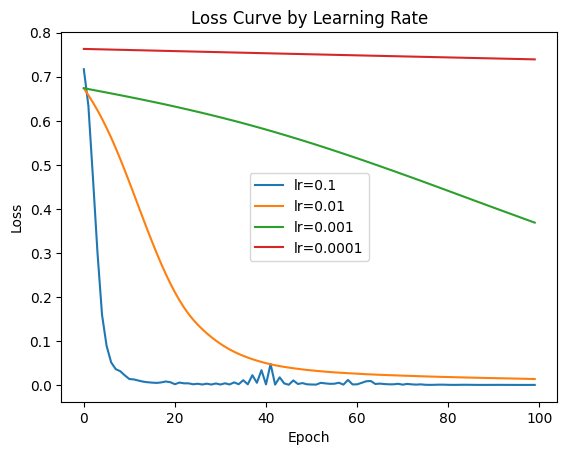

In [5]:
# 연습문제 4
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 데이터 생성
X = torch.randn(200, 4)
y = (X[:, 0] + X[:, 1] > 0).long()

# 학습 함수
def train_model(lr):

    model = nn.Sequential(
        nn.Linear(4, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 2)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(100):
        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

# Learning rates
learning_rates = [0.1, 0.01, 0.001, 0.0001]

loss_history = {}

for lr in learning_rates:
    loss_history[lr] = train_model(lr)

# 그래프
plt.figure()

for lr in learning_rates:
    plt.plot(loss_history[lr], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve by Learning Rate")
plt.legend()
plt.show()